# Analisis Perilaku Pelanggan Jaringan Kios Offline

**Customer Segmentation · Repeat Visit Analysis · Predictive Modeling · High-Value Customer Prioritization**

## Business Context

Sebuah jaringan kios offline ingin memahami perilaku pelanggannya untuk menjawab tiga pertanyaan utama:

1. Bagaimana pelanggan dapat dikelompokkan berdasarkan perilaku dan nilai transaksi?
2. Faktor apa pada kunjungan pertama yang berkaitan dengan kemungkinan pelanggan melakukan kunjungan kembali?
3. Bagaimana perusahaan dapat memprioritaskan pelanggan yang memiliki potensi nilai tinggi?

Analisis dilakukan menggunakan dua dataset:

- `customers.csv`
- `kiosk_visits.csv`

Analisis mencakup:
- data quality validation
- customer segmentation menggunakan K-Means
- repeat visit analysis menggunakan Logistic Regression
- model comparison menggunakan Linear Discriminant Analysis (LDA)
- high-value customer prioritization

> **Important:** Analisis prediktif menggunakan informasi dari kunjungan pertama sebagai predictor untuk menghindari data leakage dari kunjungan berikutnya.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    silhouette_score
)

pd.set_option("display.max_columns", None)

customers = pd.read_csv("/content/customers.csv")
visits = pd.read_csv("/content/kiosk_visits.csv")

visits["visit_date"] = pd.to_datetime(visits["visit_date"])

print("customers:", customers.shape)
print("visits:", visits.shape)

customers: (500, 6)
visits: (1116, 11)


## 0. Data Quality Check

Sebelum melakukan analisis, dilakukan pemeriksaan terhadap:

- Missing values
- Duplicate rows
- Unique customer IDs
- Referential integrity antara kedua dataset
- Konsistensi customer-level summary dengan visit-level data

In [ ]:
print("=== DATA QUALITY CHECK ===")

print("\nMissing values:")
print("Customers:", customers.isna().sum().sum())
print("Visits:", visits.isna().sum().sum())

print("\nDuplicate rows:")
print("Customers:", customers.duplicated().sum())
print("Visits:", visits.duplicated().sum())

print("\nUnique customers:")
print("Customers:", customers["customer_id"].nunique())
print("Visits:", visits["customer_id"].nunique())

print("\nReferential integrity:")
print(
    visits["customer_id"]
    .isin(customers["customer_id"])
    .all()
)

=== DATA QUALITY CHECK ===

Missing values:
Customers: 0
Visits: 0

Duplicate rows:
Customers: 0
Visits: 0

Unique customers:
Customers: 500
Visits: 500

Referential integrity:
True


In [ ]:
visit_summary = (
    visits.groupby("customer_id")
    .agg(
        total_visits=("visit_number", "count"),
        total_spend=("spend_amount", "sum"),
        avg_basket_value=("spend_amount", "mean")
    )
    .reset_index()
)

reconciliation = (
    customers[
        [
            "customer_id",
            "total_visits",
            "total_spend",
            "avg_basket_value"
        ]
    ]
    .merge(
        visit_summary,
        on="customer_id",
        suffixes=("_customer", "_visit")
    )
)

print(
    "Total visits match:",
    np.allclose(
        reconciliation["total_visits_customer"],
        reconciliation["total_visits_visit"]
    )
)

print(
    "Total spend match:",
    np.allclose(
        reconciliation["total_spend_customer"],
        reconciliation["total_spend_visit"]
    )
)

print(
    "Average basket value match:",
    np.allclose(
        reconciliation["avg_basket_value_customer"],
        reconciliation["avg_basket_value_visit"]
    )
)

Total visits match: True
Total spend match: True
Average basket value match: True


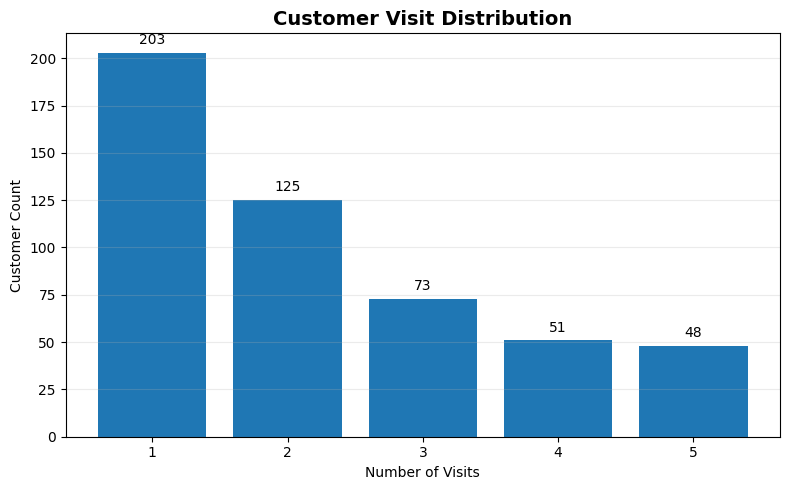

In [ ]:
# Visualisasi: Distribusi Jumlah Kunjungan Customer

visit_distribution = (visit_summary["total_visits"].value_counts().sort_index())

plt.figure(figsize=(8, 5))
bars = plt.bar(
    visit_distribution.index.astype(str),
    visit_distribution.values
)

plt.title(
    "Customer Visit Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Visits")
plt.ylabel("Customer Count")

plt.grid(
    axis="y",
    alpha=0.25
)

# Menampilkan jumlah customer di atas setiap bar
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 3,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Insight

**Kunjungan berulang sudah menjadi bagian penting dari basis pelanggan.**

Dari **500 pelanggan**, **297 pelanggan (59,4%)** melakukan lebih dari satu kunjungan, sementara **203 pelanggan (40,6%)** hanya berkunjung sekali.

Meskipun pelanggan yang hanya berkunjung sekali merupakan kelompok terbesar, mayoritas basis pelanggan telah kembali setidaknya sekali. Ini menunjukkan bahwa pemahaman tentang **perilaku kunjungan berulang** dapat memberikan peluang yang berarti untuk analisis retensi pelanggan.

Oleh karena itu, bagian selanjutnya berfokus pada identifikasi apakah karakteristik yang diamati selama **kunjungan pertama** terkait dengan kemungkinan untuk kembali.

## Catatan Penting: Menghindari Data Leakage

`customers.csv` berisi metrik pelanggan berdasarkan seluruh riwayat kunjungan, seperti:

- `total_visits`
- `total_spend`
- `avg_basket_value`

Variabel tersebut digunakan pada **Bagian A** karena segmentasi bertujuan untuk menggambarkan perilaku pelanggan berdasarkan riwayat yang sudah terjadi.

Namun, penggunaan variabel full-history untuk memprediksi perilaku di masa depan dapat menyebabkan **data leakage**, karena variabel tersebut sudah mengandung informasi dari kunjungan berikutnya.

Oleh karena itu:

- **Bagian A:** menggunakan seluruh riwayat pelanggan untuk segmentasi.
- **Bagian B, C, dan D:** menggunakan informasi dari kunjungan pertama sebagai variabel prediktor.

Dengan pendekatan ini, model prediksi hanya menggunakan informasi yang tersedia setelah kunjungan pertama dan tidak menggunakan informasi dari kunjungan di masa depan.

In [ ]:
agg = (
    visits.groupby("customer_id")
    .agg(
        avg_dwell=("dwell_time_minutes", "mean"),
        promo_exposure_rate=("promo_exposed", "mean"),
        avg_items=("items_purchased", "mean"),
        weekday_rate=("weekday_flag", "mean")
    )
    .reset_index()
)

df_full = customers.merge(
    agg,
    on="customer_id",
    how="left"
)

df_full["repeat_visitor"] = (
    df_full["total_visits"] > 1
).astype(int)

df_full.head()

,customer_id,age_band,gender,total_visits,total_spend,avg_basket_value,avg_dwell,promo_exposure_rate,avg_items,weekday_rate,repeat_visitor
0,C0001,25-34,F,1,15.76,15.760,17.451815,0.000000,2.0,1.000000,0
1,C0002,55+,M,3,47.91,15.970,12.431708,0.666667,2.0,0.666667,1
2,C0003,35-44,M,2,15.29,7.645,12.440900,0.000000,1.0,0.500000,1
3,C0004,35-44,M,2,17.58,8.790,14.269929,0.500000,1.0,1.000000,1
4,C0005,18-24,M,2,7.23,3.615,12.499139,0.000000,2.0,0.500000,1


In [ ]:
segment_features = [
    "total_visits",
    "avg_basket_value",
    "avg_dwell",
    "promo_exposure_rate",
    "avg_items",
    "weekday_rate"
]

X_segment = df_full[segment_features]

scaler_segment = StandardScaler()

X_segment_scaled = scaler_segment.fit_transform(
    X_segment
)

In [ ]:
silhouette_results = []

for k in [3, 4, 5]:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_segment_scaled)

    silhouette_results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(
            X_segment_scaled,
            labels
        )
    })

silhouette_df = pd.DataFrame(
    silhouette_results
)

silhouette_df

,k,inertia,silhouette
0,3,2122.471253,0.165961
1,4,1897.743010,0.191118
2,5,1716.347904,0.198209


### Cluster Selection

K=5 menghasilkan silhouette yang sedikit lebih tinggi dibanding K=4.

Namun, K=4 dipilih karena memberikan segmentasi yang lebih sederhana, interpretable, dan actionable untuk keputusan bisnis.

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_full["segment"] = kmeans.fit_predict(
    X_segment_scaled
)

In [ ]:
segment_profile = (
    df_full
    .groupby("segment")
    .agg(
        total_visits=("total_visits", "mean"),
        avg_basket_value=("avg_basket_value", "mean"),
        avg_dwell=("avg_dwell", "mean"),
        promo_exposure_rate=("promo_exposure_rate", "mean"),
        avg_items=("avg_items", "mean"),
        weekday_rate=("weekday_rate", "mean"),
        total_spend=("total_spend", "mean"),
        n_customers=("customer_id", "count"),
        repeat_rate=("repeat_visitor", "mean")
    )
)

segment_profile["revenue_share"] = (
    df_full
    .groupby("segment")["total_spend"]
    .sum()
    / df_full["total_spend"].sum()
)

segment_profile["customer_share"] = (
    segment_profile["n_customers"]
    / len(df_full)
)

segment_profile.round(3)

,total_visits,avg_basket_value,avg_dwell,promo_exposure_rate,avg_items,weekday_rate,total_spend,n_customers,repeat_rate,revenue_share,customer_share
segment,,,,,,,,,,,
0,1.623,1.896,11.765,0.327,0.434,0.663,3.801,154,0.500,0.075,0.308
1,1.384,11.616,13.262,0.010,2.108,0.682,15.506,99,0.313,0.197,0.198
2,4.065,6.827,12.197,0.402,1.404,0.753,27.934,138,1.000,0.494,0.276
3,1.541,11.047,12.193,0.827,1.911,0.742,16.780,109,0.468,0.234,0.218


In [ ]:
segment_names = {
    2: "Loyal Regulars",
    3: "Promo-Driven Shoppers",
    1: "High-Value One-Timers",
    0: "Low-Value Browsers"
}

segment_profile["segment_name"] = (
    segment_profile.index
    .map(segment_names)
)

segment_final = (
    segment_profile[
        [
            "segment_name",
            "n_customers",
            "customer_share",
            "revenue_share",
            "total_visits",
            "avg_basket_value",
            "repeat_rate"
        ]
    ]
    .sort_values(
        "revenue_share",
        ascending=False
    )
)

segment_final.round(3)

,segment_name,n_customers,customer_share,revenue_share,total_visits,avg_basket_value,repeat_rate
segment,,,,,,,
2,Loyal Regulars,138,0.276,0.494,4.065,6.827,1.000
3,Promo-Driven Shoppers,109,0.218,0.234,1.541,11.047,0.468
1,High-Value One-Timers,99,0.198,0.197,1.384,11.616,0.313
0,Low-Value Browsers,154,0.308,0.075,1.623,1.896,0.500


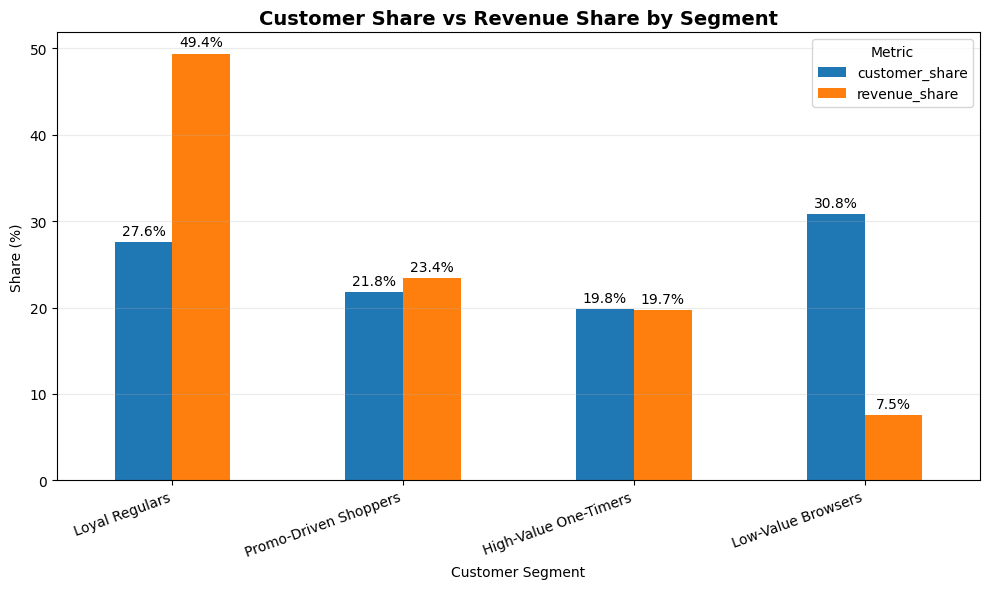

In [ ]:
# Visualisasi: Customer Share dan Revenue Share per Segment

segment_visual = (segment_final.set_index("segment_name")[["customer_share", "revenue_share"]]* 100)

ax = segment_visual.plot(kind="bar",figsize=(10, 6))

plt.title("Customer Share vs Revenue Share by Segment",fontsize=14,fontweight="bold")

plt.xlabel("Customer Segment")
plt.ylabel("Share (%)")

plt.xticks(rotation=20,ha="right")
plt.legend(title="Metric")
plt.grid(axis="y",alpha=0.25)

# Tambahkan nilai di atas setiap bar
for container in ax.containers:ax.bar_label(container,fmt="%.1f%%",padding=3)

plt.tight_layout()
plt.show()

### Insight

**Kontribusi pelanggan tidak proporsional dengan kontribusi pendapatan.**

**Pelanggan Setia Reguler** hanya mewakili **27,6% dari basis pelanggan**, tetapi menyumbang **49,4% dari total pendapatan**. Ini menunjukkan bahwa kelompok pelanggan setia yang relatif kecil menghasilkan pangsa nilai pelanggan yang sangat besar.

Sebaliknya, **Pengunjung dengan Nilai Rendah** menyumbang pangsa pelanggan terbesar yaitu **30,8%**, tetapi hanya menyumbang **7,5% dari pendapatan**.

Hal ini menyoroti dua peluang bisnis yang berbeda:

- **Pelanggan Setia Reguler:** prioritaskan retensi, loyalitas, dan penjualan silang untuk melindungi segmen dengan kontribusi pendapatan terkuat.

- **Pengunjung dengan Nilai Rendah:** identifikasi peluang untuk meningkatkan keterlibatan, frekuensi kunjungan, atau nilai transaksi.

Dua segmen lainnya menunjukkan hubungan yang lebih seimbang antara pangsa pelanggan dan pangsa pendapatan mereka.

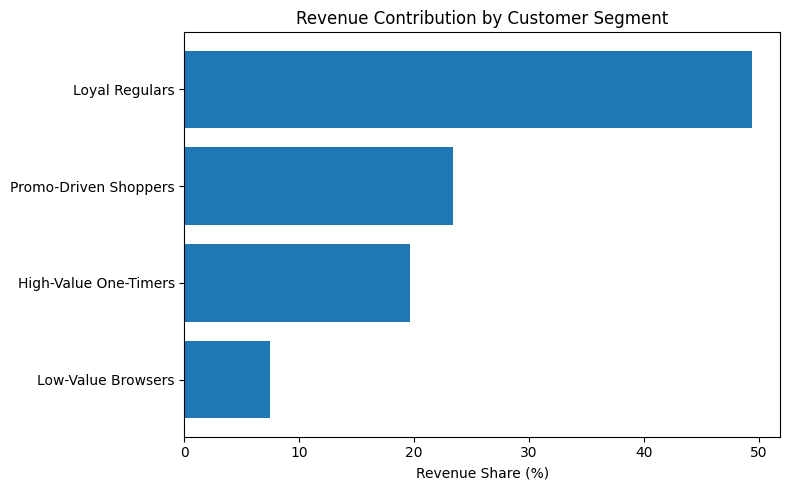

In [ ]:
plot_df = (
    segment_final
    .sort_values("revenue_share")
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_df["segment_name"],
    plot_df["revenue_share"] * 100
)

plt.xlabel("Revenue Share (%)")
plt.title("Revenue Contribution by Customer Segment")

plt.tight_layout()
plt.show()

## Insight Segmentasi Pelanggan

Berdasarkan hasil K-Means dengan 4 cluster, pelanggan dapat dikelompokkan menjadi empat segmen dengan karakteristik perilaku yang berbeda:

1. **Loyal Regulars**  
   Pelanggan dengan frekuensi kunjungan paling tinggi. Mereka merupakan pelanggan yang paling sering kembali dan memberikan kontribusi revenue terbesar. Segmen ini menjadi kelompok pelanggan yang paling penting untuk dipertahankan.

2. **Promo-Driven Shoppers**  
   Pelanggan dengan paparan promo yang relatif tinggi. Mereka memiliki nilai belanja yang cukup baik dan sebagian besar menunjukkan potensi untuk melakukan kunjungan kembali. Program promo dan penawaran yang relevan dapat digunakan untuk menjaga engagement segmen ini.

3. **High-Value One-Timers**  
   Pelanggan yang memiliki nilai belanja relatif tinggi tetapi frekuensi kunjungannya masih rendah. Segmen ini memiliki peluang untuk dikembangkan menjadi pelanggan berulang melalui strategi follow-up dan penawaran yang relevan setelah kunjungan pertama.

4. **Low-Value Browsers**  
   Pelanggan dengan nilai belanja dan jumlah item yang relatif rendah. Segmen ini memiliki kontribusi revenue paling kecil sehingga strategi yang diterapkan sebaiknya berfokus pada peningkatan nilai transaksi secara bertahap.

### Kesimpulan

Segmentasi menunjukkan bahwa pelanggan tidak hanya berbeda berdasarkan frekuensi kunjungan dan nilai belanja, tetapi juga berdasarkan pola perilaku seperti paparan promo, jumlah item yang dibeli, durasi kunjungan, dan pola kunjungan pada hari kerja.

Dari sisi bisnis, **Loyal Regulars** menjadi segmen utama yang perlu dipertahankan, sementara **High-Value One-Timers** menjadi peluang untuk meningkatkan repeat visit dan **Low-Value Browsers** dapat diarahkan untuk meningkatkan nilai transaksi.

In [ ]:
# Ambil kunjungan pertama berdasarkan visit_number = 1
first_visit = (
    visits[
        visits["visit_number"] == 1
    ]
    .copy()
)

# Rename kolom agar jelas bahwa fitur berasal dari kunjungan pertama
first_visit = first_visit.rename(
    columns={
        "dwell_time_minutes": "first_dwell",
        "promo_exposed": "first_promo_exposed",
        "spend_amount": "first_spend",
        "items_purchased": "first_items",
        "weekday_flag": "first_weekday",
        "city": "first_city",
        "payment_type": "first_payment"
    }
)

# Pilih kolom yang akan digunakan
first_visit = first_visit[
    [
        "customer_id",
        "first_dwell",
        "first_promo_exposed",
        "first_spend",
        "first_items",
        "first_weekday",
        "first_city",
        "first_payment"
    ]
]

# Validasi bahwa setiap customer memiliki tepat satu visit pertama
print("=== FIRST VISIT VALIDATION ===")
print(
    "Number of visit #1 records:",
    len(first_visit)
)
print(
    "Unique customers:",
    first_visit["customer_id"].nunique()
)
print(
    "Duplicate customer IDs:",
    first_visit["customer_id"].duplicated().sum()
)

=== FIRST VISIT VALIDATION ===
Number of visit #1 records: 500
Unique customers: 500
Duplicate customer IDs: 0


In [ ]:
df_model = customers.merge(
    first_visit,
    on="customer_id",
    how="left"
)

df_model["repeat_visitor"] = (
    df_model["total_visits"] > 1
).astype(int)

print("Modeling Dataset:", df_model.shape)
print(
    "Missing Values:",
    df_model.isna().sum().sum()
)

print("\nRepeat Distribution:")
print(
    df_model["repeat_visitor"]
    .value_counts()
    .sort_index()
)

Modeling Dataset: (500, 14)
Missing Values: 0

Repeat Distribution:
repeat_visitor
0    203
1    297
Name: count, dtype: int64


In [ ]:
repeat_rate = (
    df_model["repeat_visitor"].mean()
)

print(
    f"Repeat Visitor Rate: {repeat_rate:.1%}"
)

Repeat Visitor Rate: 59.4%


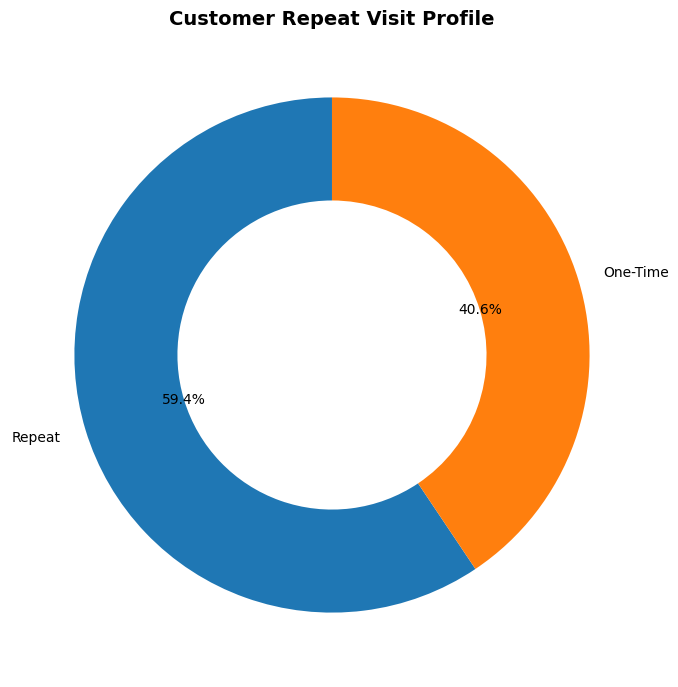

In [ ]:
# Visualisasi: Repeat Visitor vs One-Time Customer

repeat_counts = (
    df_model["repeat_visitor"]
    .map({
        0: "One-Time",
        1: "Repeat"
    })
    .value_counts()
    .reindex(["Repeat", "One-Time"])
)

plt.figure(figsize=(7, 7))

plt.pie(
    repeat_counts.values,
    labels=repeat_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={
        "width": 0.4
    }
)

plt.title(
    "Customer Repeat Visit Profile",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Insight
**Pelanggan tetap merupakan mayoritas dari basis pelanggan.**

Dari **500 pelanggan**, **297 pelanggan (59,4%)** melakukan kunjungan lebih dari satu kali, sementara **203 pelanggan (40,6%)** hanya berkunjung sekali.

Basis pelanggan tetap yang relatif besar menunjukkan bahwa retensi pelanggan sudah menjadi bagian penting dari bisnis kios. Namun, **kelompok pelanggan satu kali sebesar 40,6%** juga mewakili peluang besar untuk keterlibatan lebih lanjut.

Analisis selanjutnya meneliti apakah karakteristik yang diamati selama **kunjungan pertama** terkait dengan kemungkinan pelanggan kembali.

In [ ]:
repeat_model = smf.logit(
    """
    repeat_visitor ~
    first_spend +
    first_items +
    first_promo_exposed +
    first_dwell
    """,
    data=df_model
).fit()

print(repeat_model.summary())

Optimization terminated successfully.
         Current function value: 0.665094
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:         repeat_visitor   No. Observations:                  500
Model:                          Logit   Df Residuals:                      495
Method:                           MLE   Df Model:                            4
Date:                Sat, 05 Sep 2026   Pseudo R-squ.:                 0.01522
Time:                        05:23:57   Log-Likelihood:                -332.55
converged:                       True   LL-Null:                       -337.68
Covariance Type:            nonrobust   LLR p-value:                   0.03603
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.7609      0.279      2.726      0.006       0.214       1.308
fi

In [ ]:
repeat_odds = pd.DataFrame({
    "coefficient": repeat_model.params,
    "odds_ratio": np.exp(
        repeat_model.params
    ),
    "p_value": repeat_model.pvalues,
    "CI_lower": np.exp(
        repeat_model.conf_int()[0]
    ),
    "CI_upper": np.exp(
        repeat_model.conf_int()[1]
    )
})

repeat_odds.round(4)

,coefficient,odds_ratio,p_value,CI_lower,CI_upper
Intercept,0.7609,2.1403,0.0064,1.2384,3.6990
first_spend,-0.0418,0.9591,0.0037,0.9324,0.9865
first_items,0.1588,1.1721,0.0944,0.9731,1.4118
first_promo_exposed,-0.0824,0.9209,0.6613,0.6371,1.3313
first_dwell,-0.0219,0.9784,0.2389,0.9434,1.0146


In [ ]:
# Evaluasi Logistic Regression dengan 5-Fold Cross-Validation

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix
)

# Features dan target
behavior_features = [
    "first_spend",
    "first_items",
    "first_promo_exposed",
    "first_dwell"
]

X_repeat = df_model[behavior_features]
y_repeat = df_model["repeat_visitor"]

# 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Pipeline:
# scaling dilakukan di dalam setiap fold untuk menghindari data leakage
repeat_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

# Prediksi out-of-fold
cv_probability = cross_val_predict(
    repeat_pipeline,
    X_repeat,
    y_repeat,
    cv=cv,
    method="predict_proba"
)[:, 1]

cv_prediction = (
    cv_probability >= 0.5
).astype(int)

# Baseline
baseline_accuracy = y_repeat.mean()

# Cross-validation metrics
cv_accuracy = accuracy_score(
    y_repeat,
    cv_prediction
)

cv_auc = roc_auc_score(
    y_repeat,
    cv_probability
)

print(
    f"Baseline Accuracy: {baseline_accuracy:.3f}"
)

print(
    f"5-Fold CV Accuracy: {cv_accuracy:.3f}"
)

print(
    f"Accuracy Improvement: "
    f"{cv_accuracy - baseline_accuracy:.3f}"
)

print(
    f"5-Fold CV ROC-AUC: {cv_auc:.3f}"
)

print("\nCross-Validation Confusion Matrix:")
print(
    confusion_matrix(
        y_repeat,
        cv_prediction
    )
)

print(
    "\nIn-sample Pseudo R²:",
    round(repeat_model.prsquared, 4)
)

Baseline Accuracy: 0.594
5-Fold CV Accuracy: 0.604
Accuracy Improvement: 0.010
5-Fold CV ROC-AUC: 0.526

Cross-Validation Confusion Matrix:
[[ 30 173]
 [ 25 272]]

In-sample Pseudo R²: 0.0152


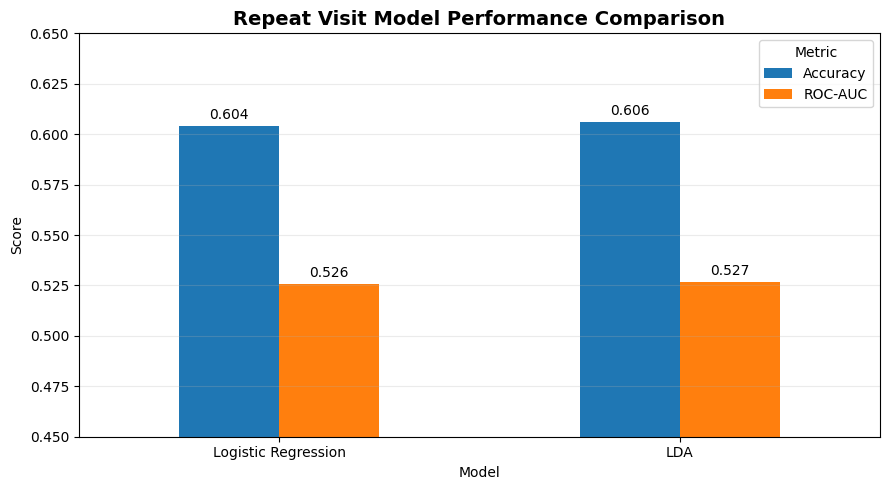

In [43]:
# Visualisasi: Perbandingan Performa Model

model_comparison = pd.DataFrame({"Model": ["Logistic Regression","LDA"],
    "Accuracy": [logistic_cv_accuracy,lda_cv_accuracy],
    "ROC-AUC": [logistic_cv_auc,lda_cv_auc]
})

ax = model_comparison.set_index("Model").plot(kind="bar",figsize=(9, 5))

plt.title("Repeat Visit Model Performance Comparison",fontsize=14,fontweight="bold")
plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0.45, 0.65)
plt.xticks(rotation=0)

plt.legend(title="Metric")
plt.grid(axis="y",alpha=0.25)

for container in ax.containers:ax.bar_label(container,fmt="%.3f",padding=3)

plt.tight_layout()
plt.show()

### Insight

**LDA tidak memberikan peningkatan prediktif yang signifikan dibandingkan Regresi Logistik.**

Kedua model menghasilkan hasil yang hampir identik di bawah validasi silang 5-fold:

- Regresi Logistik: **Akurasi 60,4%**, **ROC-AUC 0,526**
- LDA: **Akurasi 60,6%**, **ROC-AUC 0,527**

Perbedaannya hanya **0,2 poin persentase dalam akurasi** dan **0,001 dalam ROC-AUC**.

Oleh karena itu, **Regresi Logistik** yang lebih sederhana dan lebih mudah diinterpretasikan tetap menjadi pendekatan yang lebih disukai untuk interpretasi bisnis, sementara LDA berfungsi sebagai validasi alternatif yang berguna untuk hasil pemodelan.

## Kesimpulan Analisis Repeat Visit

Dari 500 pelanggan, sebanyak **297 pelanggan (59,4%)** melakukan lebih dari satu kunjungan, sedangkan **203 pelanggan (40,6%)** hanya melakukan satu kunjungan.

Berdasarkan Logistic Regression menggunakan karakteristik pada kunjungan pertama:

- **First spend** merupakan satu-satunya variabel yang signifikan secara statistik pada taraf 5% (OR = **0,959**; p = **0,0037**). Setiap kenaikan satu unit first spend berkaitan dengan sekitar **4,1% penurunan odds** pelanggan melakukan repeat visit, dengan variabel lain dianggap konstan.
- **First items** menunjukkan arah hubungan positif (OR = **1,172**), tetapi belum signifikan secara statistik pada taraf 5% (p = **0,0944**).
- **Promo exposure** (p = **0,6613**) dan **dwell time** (p = **0,2389**) tidak menunjukkan hubungan yang signifikan dengan repeat visit.

### Evaluasi Model

Evaluasi menggunakan **5-fold stratified cross-validation** menghasilkan:

- Baseline Accuracy: **59,4%**
- CV Accuracy: **60,4%**
- CV ROC-AUC: **0,526**
- In-sample McFadden Pseudo R²: **0,0152**

Model hanya meningkatkan accuracy sekitar **1,0 percentage point** dibandingkan baseline dan menghasilkan ROC-AUC yang mendekati 0,5.

### Business Interpretation

Hasil ini menunjukkan bahwa karakteristik kunjungan pertama yang tersedia dalam dataset memiliki **kemampuan prediktif yang terbatas** untuk mengidentifikasi pelanggan yang akan melakukan repeat visit.

Meskipun first spend menunjukkan hubungan statistik dengan repeat visit, hasil ini merupakan **asosiasi dan tidak dapat diinterpretasikan sebagai hubungan sebab-akibat**.

Untuk meningkatkan kemampuan prediksi repeat visit, analisis berikutnya dapat mempertimbangkan informasi tambahan seperti recency, jarak antar kunjungan, kategori produk, respons terhadap promosi, channel acquisition, atau customer engagement apabila data tersebut tersedia.

In [ ]:
# Features untuk analisis LDA
behavior_features = [
    "first_spend",
    "first_items",
    "first_promo_exposed",
    "first_dwell"
]

X = df_model[behavior_features]
y = df_model["repeat_visitor"]

print("LDA Features:")
print(behavior_features)

print("\nDataset Shape:", X.shape)
print("Target Distribution:")
print(y.value_counts())

LDA Features:
['first_spend', 'first_items', 'first_promo_exposed', 'first_dwell']

Dataset Shape: (500, 4)
Target Distribution:
repeat_visitor
1    297
0    203
Name: count, dtype: int64


In [ ]:
# Fit LDA pada seluruh dataset
lda = LinearDiscriminantAnalysis()

lda.fit(X,y)

# Prediksi in-sample
lda_prediction = lda.predict(X)
lda_probability = (lda.predict_proba(X)[:, 1])
lda_accuracy = accuracy_score(y,lda_prediction)
lda_auc = roc_auc_score(y,lda_probability)

print(f"In-sample LDA Accuracy: "f"{lda_accuracy:.3f}")
print(f"In-sample LDA ROC-AUC: "f"{lda_auc:.3f}")

In-sample LDA Accuracy: 0.616
In-sample LDA ROC-AUC: 0.560


In [ ]:
lda_coefficients = pd.DataFrame({
    "feature": behavior_features,
    "coefficient": lda.coef_[0]
})

lda_coefficients

,feature,coefficient
0,first_spend,-0.042516
1,first_items,0.158682
2,first_promo_exposed,-0.084306
3,first_dwell,-0.021760


In [ ]:
# 5-Fold Cross-Validation untuk LDA

from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, roc_auc_score

# Pipeline: scaling dilakukan di dalam setiap fold
lda_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearDiscriminantAnalysis())
])

# Stratified 5-Fold Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Out-of-fold probability prediction
lda_cv_probability = cross_val_predict(
    lda_pipeline,X,y,
    cv=cv,
    method="predict_proba"
)[:, 1]

# Out-of-fold class prediction
lda_cv_prediction = (
    lda_cv_probability >= 0.5
).astype(int)

# Evaluation metrics
lda_cv_accuracy = accuracy_score(y,lda_cv_prediction)
lda_cv_auc = roc_auc_score(y,lda_cv_probability)

print(f"5-Fold CV LDA Accuracy: "f"{lda_cv_accuracy:.3f}")
print(f"5-Fold CV LDA ROC-AUC: "f"{lda_cv_auc:.3f}")

5-Fold CV LDA Accuracy: 0.606
5-Fold CV LDA ROC-AUC: 0.527


In [ ]:
# Perbandingan Logistic Regression dan LDA
# menggunakan 5-Fold Stratified Cross-Validation

logistic_cv_probability = cross_val_predict(
    repeat_pipeline,X,y,cv=cv,
    method="predict_proba"
)[:, 1]

logistic_cv_prediction = (logistic_cv_probability >= 0.5).astype(int)
logistic_cv_accuracy = accuracy_score(y,logistic_cv_prediction)
logistic_cv_auc = roc_auc_score(y,logistic_cv_probability)

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression","LDA"],
    "CV Accuracy": [logistic_cv_accuracy, lda_cv_accuracy],
    "CV ROC-AUC": [logistic_cv_auc,lda_cv_auc
    ]
})

model_comparison.round(3)

,Model,CV Accuracy,CV ROC-AUC
0,Logistic Regression,0.604,0.526
1,LDA,0.606,0.527


In [ ]:
# Perbandingan prediksi out-of-fold antara Logistic Regression dan LDA

prediction_agreement = (logistic_cv_prediction == lda_cv_prediction).mean()
print(f"5-Fold CV Prediction Agreement: "f"{prediction_agreement:.3f}")

5-Fold CV Prediction Agreement: 0.998


## Kesimpulan Analisis LDA

LDA digunakan sebagai pendekatan alternatif untuk mengevaluasi apakah karakteristik pada kunjungan pertama dapat membedakan pelanggan yang melakukan repeat visit dan pelanggan yang hanya melakukan satu kunjungan.

Hasil evaluasi menggunakan **5-fold stratified cross-validation** menunjukkan:

- **LDA Accuracy:** 60,6%
- **LDA ROC-AUC:** 0,527
- **Logistic Regression Accuracy:** 60,4%
- **Logistic Regression ROC-AUC:** 0,526
- **Prediction Agreement:** 99,8%

Kedua model menghasilkan performa yang sangat mirip. LDA hanya unggul sekitar **0,2 percentage point** dalam accuracy dan **0,001** dalam ROC-AUC dibandingkan Logistic Regression.

Tingginya prediction agreement (99,8%) menunjukkan bahwa kedua pendekatan memberikan hasil klasifikasi yang hampir identik. Namun, ROC-AUC yang mendekati 0,5 menunjukkan bahwa kemampuan kedua model dalam membedakan repeat visitor dan non-repeat visitor masih **terbatas**.

Dengan demikian, tidak terdapat bukti bahwa LDA memberikan peningkatan prediktif yang berarti dibandingkan Logistic Regression. Untuk kebutuhan analisis bisnis, **Logistic Regression tetap lebih mudah diinterpretasikan** karena memberikan odds ratio dan confidence interval yang dapat digunakan untuk menjelaskan hubungan antara karakteristik kunjungan pertama dan repeat visit.

In [ ]:
# Membentuk target future spend berdasarkan transaksi setelah kunjungan pertama

future_spend = (visits[visits["visit_number"] > 1]
    .groupby("customer_id")["spend_amount"]
    .sum()
    .rename("future_spend")
)

# Gabungkan future spend ke modeling dataset
df_model = df_model.drop(
    columns=["future_spend", "high_value"],
    errors="ignore"
)

df_model = df_model.merge(future_spend,on="customer_id",how="left")

# Customer tanpa kunjungan berikutnya memiliki future spend = 0
df_model["future_spend"] = (df_model["future_spend"].fillna(0))

# Definisikan high-value berdasarkan top 33% future spend
high_value_threshold = (df_model["future_spend"].quantile(0.67))

df_model["high_value"] = (
    df_model["future_spend"]
    >= high_value_threshold
).astype(int)

print(f"Future Spend Threshold: "f"{high_value_threshold:.4f}")

print("\nFuture Spend Summary:")
print(df_model["future_spend"].describe())

print("\nHigh-Value Distribution:")
print(df_model["high_value"].value_counts().sort_index())

Future Spend Threshold: 9.8058

Future Spend Summary:
count    500.000000
mean       8.787700
std       12.803969
min        0.000000
25%        0.000000
50%        0.000000
75%       14.757500
max       61.910000
Name: future_spend, dtype: float64

High-Value Distribution:
high_value
0    335
1    165
Name: count, dtype: int64


In [ ]:
high_value_model = smf.logit(
    """
    high_value ~
    first_spend +
    first_items +
    first_promo_exposed +
    first_dwell +
    C(age_band) +
    C(gender)
    """,
    data=df_model
).fit()

print(
    high_value_model.summary()
)

Optimization terminated successfully.
         Current function value: 0.617890
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:             high_value   No. Observations:                  500
Model:                          Logit   Df Residuals:                      490
Method:                           MLE   Df Model:                            9
Date:                Sat, 05 Sep 2026   Pseudo R-squ.:                 0.02569
Time:                        05:39:06   Log-Likelihood:                -308.94
converged:                       True   LL-Null:                       -317.09
Covariance Type:            nonrobust   LLR p-value:                   0.06109
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.0439      0.359     -0.122      0.903      -0.748       0.660

In [ ]:
high_value_odds = pd.DataFrame({
    "coefficient": high_value_model.params,
    "odds_ratio": np.exp(
        high_value_model.params
    ),
    "p_value": high_value_model.pvalues,
    "CI_lower": np.exp(
        high_value_model.conf_int()[0]
    ),
    "CI_upper": np.exp(
        high_value_model.conf_int()[1]
    )
})

high_value_odds.round(4)

,coefficient,odds_ratio,p_value,CI_lower,CI_upper
Intercept,-0.0439,0.9571,0.9028,0.4733,1.9353
C(age_band)[T.25-34],-0.5749,0.5628,0.0434,0.3222,0.9831
C(age_band)[T.35-44],-0.0340,0.9666,0.8998,0.5691,1.6415
C(age_band)[T.45-54],-0.2962,0.7436,0.3525,0.3982,1.3886
C(age_band)[T.55+],-0.2722,0.7617,0.4430,0.3799,1.5270
C(gender)[T.M],-0.0621,0.9398,0.7502,0.6412,1.3773
first_spend,-0.0451,0.9559,0.0072,0.9249,0.9878
first_items,0.0154,1.0155,0.8762,0.8365,1.2329
first_promo_exposed,0.1108,1.1171,0.5768,0.7571,1.6483
first_dwell,-0.0154,0.9847,0.4318,0.9477,1.0232


In [ ]:
# Evaluasi High-Value Logistic Regression
# menggunakan 5-Fold Stratified Cross-Validation

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix
)

# Predictor
high_value_numeric = ["first_spend","first_items","first_promo_exposed","first_dwell"]
high_value_categorical = ["age_band","gender"]

X_high_value = df_model[high_value_numeric + high_value_categorical]
y_high_value = df_model["high_value"]

# Preprocessing
preprocessor = ColumnTransformer([
    ("numeric",StandardScaler(),high_value_numeric),
    ("categorical",OneHotEncoder(drop="first",handle_unknown="ignore"),high_value_categorical)
])

# Logistic Regression pipeline
high_value_pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("model",LogisticRegression(max_iter=1000,random_state=42))
])

# 5-Fold Stratified CV
high_value_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Out-of-fold predictions
high_value_cv_probability = cross_val_predict(
    high_value_pipeline,
    X_high_value,
    y_high_value,
    cv=high_value_cv,
    method="predict_proba"
)[:, 1]

high_value_cv_prediction = (high_value_cv_probability >= 0.5).astype(int)

# Evaluation
high_value_baseline = (y_high_value.value_counts(normalize=True).max())
high_value_cv_accuracy = accuracy_score(y_high_value,high_value_cv_prediction)
high_value_cv_auc = roc_auc_score(y_high_value,high_value_cv_probability)

print(f"Baseline Accuracy: "f"{high_value_baseline:.3f}")
print(f"5-Fold CV Accuracy: "f"{high_value_cv_accuracy:.3f}")
print(f"Accuracy Improvement: "f"{high_value_cv_accuracy - high_value_baseline:.3f}")
print(f"5-Fold CV ROC-AUC: "f"{high_value_cv_auc:.3f}")
print("\nCross-Validation Confusion Matrix:")
print(confusion_matrix(y_high_value,high_value_cv_prediction))
print("\nIn-sample Pseudo R²:",round(high_value_model.prsquared,4))

Baseline Accuracy: 0.670
5-Fold CV Accuracy: 0.658
Accuracy Improvement: -0.012
5-Fold CV ROC-AUC: 0.538

Cross-Validation Confusion Matrix:
[[328   7]
 [164   1]]

In-sample Pseudo R²: 0.0257


In [ ]:
df_model["high_value_propensity"] = (high_value_cv_probability)

print("=== HIGH-VALUE PROPENSITY ===")
print(df_model["high_value_propensity"].describe())

=== HIGH-VALUE PROPENSITY ===
count    500.000000
mean       0.332040
std        0.086513
min        0.100606
25%        0.275561
50%        0.336415
75%        0.399769
max        0.529730
Name: high_value_propensity, dtype: float64


In [ ]:
df_model["propensity_group"] = pd.qcut(
    df_model["high_value_propensity"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High"
    ]
)

propensity_summary = (df_model.groupby("propensity_group",observed=False)
    .agg(customer_count=("customer_id","count"),
        avg_propensity=("high_value_propensity","mean"),
        actual_high_value_rate=("high_value","mean"))
    .reset_index())

propensity_summary["avg_propensity_pct"] = (propensity_summary["avg_propensity"] * 100)
propensity_summary["actual_high_value_rate_pct"] = (propensity_summary["actual_high_value_rate"] * 100)
propensity_summary

,propensity_group,customer_count,avg_propensity,actual_high_value_rate,avg_propensity_pct,actual_high_value_rate_pct
0,Low,125,0.214992,0.280,21.499247,28.0
1,Medium-Low,125,0.309676,0.288,30.967563,28.8
2,Medium-High,125,0.366199,0.400,36.619853,40.0
3,High,125,0.437294,0.352,43.729434,35.2


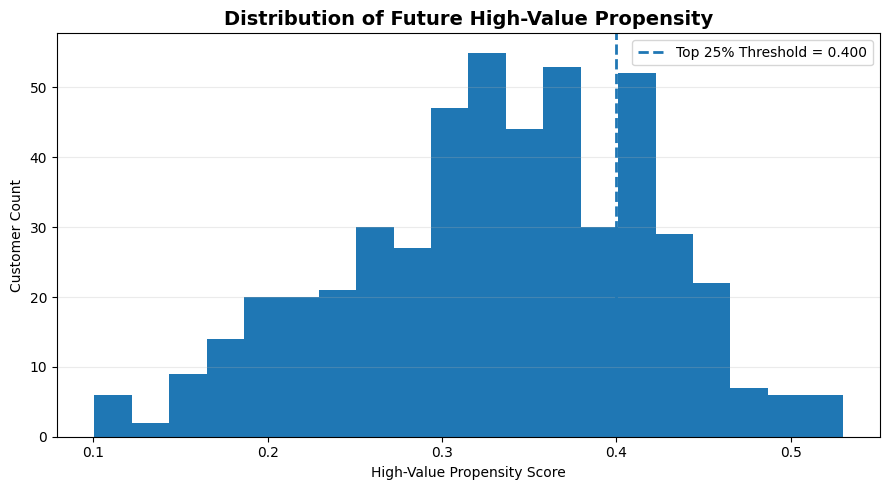

In [45]:
# Visualisasi: Distribusi Propensity Score

target_threshold = (df_model["high_value_propensity"].quantile(0.75))

plt.figure(figsize=(9, 5))

plt.hist(df_model["high_value_propensity"],bins=20)

plt.axvline(
    target_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Top 25% Threshold = {target_threshold:.3f}"
)

plt.title("Distribution of Future High-Value Propensity",fontsize=14,fontweight="bold")

plt.xlabel("High-Value Propensity Score")
plt.ylabel("Customer Count")

plt.legend()

plt.grid(axis="y",alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# Menentukan target customer berdasarkan top 25% propensity score

target_threshold = (df_model["high_value_propensity"].quantile(0.75))
target_customers = df_model[df_model["high_value_propensity"]>= target_threshold].copy()

print(f"Target Threshold (75th percentile): "f"{target_threshold:.4f}")
print(f"Target Customer Count: "f"{len(target_customers)}")
print(f"Target Customer Share: "f"{len(target_customers) / len(df_model):.1%}")
print(f"Average Propensity: "f"{target_customers['high_value_propensity'].mean():.4f}")
print(f"Actual High-Value Rate: "f"{target_customers['high_value'].mean():.1%}")

Target Threshold (75th percentile): 0.3998
Target Customer Count: 125
Target Customer Share: 25.0%
Average Propensity: 0.4373
Actual High-Value Rate: 35.2%


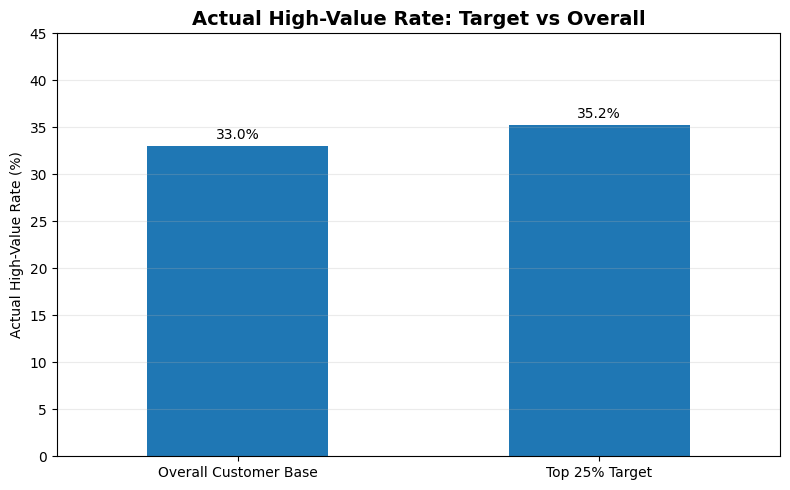

In [46]:
# Visualisasi: Actual High-Value Rate - Target vs Overall

overall_high_value_rate = df_model["high_value"].mean()
target_high_value_rate = target_customers["high_value"].mean()

comparison = pd.Series({
    "Overall Customer Base": overall_high_value_rate * 100,
    "Top 25% Target": target_high_value_rate * 100
})

ax = comparison.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Actual High-Value Rate: Target vs Overall",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("")
plt.ylabel("Actual High-Value Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 45)
plt.grid(axis="y", alpha=.25)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

In [ ]:
print("=== TARGET AGE PROFILE ===")
print(target_customers["age_band"].value_counts())

print("\n=== TARGET GENDER PROFILE ===")
print(target_customers["gender"].value_counts())

print("\n=== TARGET CITY PROFILE ===")
print(target_customers["first_city"].value_counts())

print("\n=== TARGET PROMO PROFILE ===")
print(target_customers["first_promo_exposed"].value_counts())

print("\n=== TARGET PAYMENT PROFILE ===")
print(target_customers["first_payment"].value_counts())

=== TARGET AGE PROFILE ===
age_band
18-24    47
35-44    47
45-54    18
55+       8
25-34     5
Name: count, dtype: int64

=== TARGET GENDER PROFILE ===
gender
M    63
F    62
Name: count, dtype: int64

=== TARGET CITY PROFILE ===
first_city
Medan       28
Denpasar    28
Bandung     25
Surabaya    24
Jakarta     20
Name: count, dtype: int64

=== TARGET PROMO PROFILE ===
first_promo_exposed
0    75
1    50
Name: count, dtype: int64

=== TARGET PAYMENT PROFILE ===
first_payment
card      53
cash      47
wallet    25
Name: count, dtype: int64


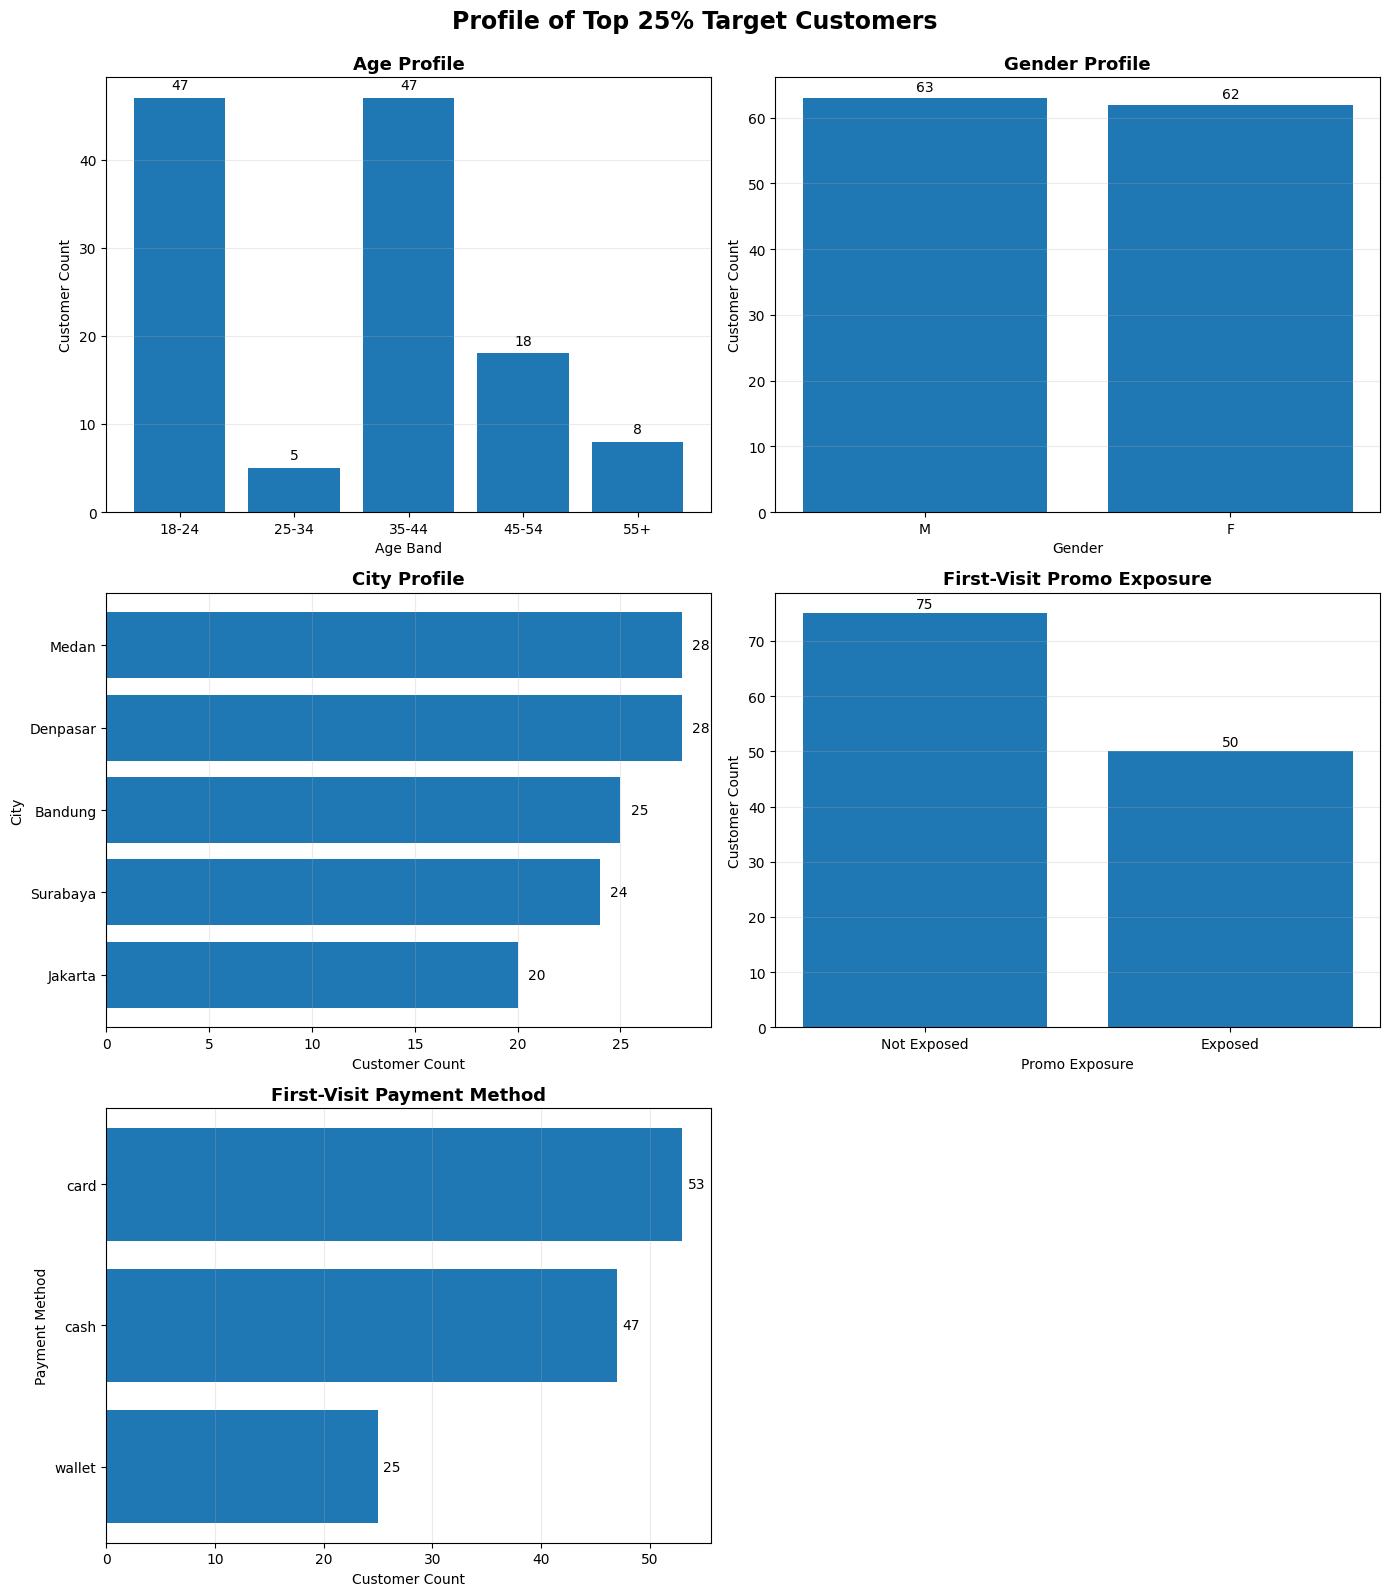

In [49]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

# --------------------------------------------------
# 1. AGE PROFILE
# --------------------------------------------------

age_order = ["18-24", "25-34", "35-44", "45-54", "55+"]

age_profile = (
    target_customers["age_band"]
    .value_counts()
    .reindex(age_order)
    .fillna(0)
)

axes[0, 0].bar(age_profile.index, age_profile.values)

axes[0, 0].set_title(
    "Age Profile",
    fontsize=13,
    fontweight="bold"
)
axes[0, 0].set_xlabel("Age Band")
axes[0, 0].set_ylabel("Customer Count")
axes[0, 0].grid(axis="y", alpha=.25)

for i, value in enumerate(age_profile.values):
    axes[0, 0].text(
        i,
        value + 1,
        f"{int(value)}",
        ha="center"
    )


# --------------------------------------------------
# 2. GENDER PROFILE
# --------------------------------------------------

gender_profile = target_customers["gender"].value_counts()

axes[0, 1].bar(
    gender_profile.index,
    gender_profile.values
)

axes[0, 1].set_title(
    "Gender Profile",
    fontsize=13,
    fontweight="bold"
)
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Customer Count")
axes[0, 1].grid(axis="y", alpha=.25)

for i, value in enumerate(gender_profile.values):
    axes[0, 1].text(
        i,
        value + 1,
        f"{int(value)}",
        ha="center"
    )


# --------------------------------------------------
# 3. CITY PROFILE
# --------------------------------------------------

city_profile = (
    target_customers["first_city"]
    .value_counts()
    .sort_values(ascending=True)
)

axes[1, 0].barh(
    city_profile.index,
    city_profile.values
)

axes[1, 0].set_title(
    "City Profile",
    fontsize=13,
    fontweight="bold"
)
axes[1, 0].set_xlabel("Customer Count")
axes[1, 0].set_ylabel("City")
axes[1, 0].grid(axis="x", alpha=.25)

for i, value in enumerate(city_profile.values):
    axes[1, 0].text(
        value + .5,
        i,
        f"{int(value)}",
        va="center"
    )


# --------------------------------------------------
# 4. PROMO EXPOSURE
# --------------------------------------------------

promo_profile = (
    target_customers["first_promo_exposed"]
    .map({0: "Not Exposed", 1: "Exposed"})
    .value_counts()
)

axes[1, 1].bar(
    promo_profile.index,
    promo_profile.values
)

axes[1, 1].set_title(
    "First-Visit Promo Exposure",
    fontsize=13,
    fontweight="bold"
)
axes[1, 1].set_xlabel("Promo Exposure")
axes[1, 1].set_ylabel("Customer Count")
axes[1, 1].grid(axis="y", alpha=.25)

for i, value in enumerate(promo_profile.values):
    axes[1, 1].text(
        i,
        value + 1,
        f"{int(value)}",
        ha="center"
    )


# --------------------------------------------------
# 5. PAYMENT METHOD
# --------------------------------------------------

payment_profile = (
    target_customers["first_payment"]
    .value_counts()
    .sort_values(ascending=True)
)

axes[2, 0].barh(
    payment_profile.index,
    payment_profile.values
)

axes[2, 0].set_title(
    "First-Visit Payment Method",
    fontsize=13,
    fontweight="bold"
)
axes[2, 0].set_xlabel("Customer Count")
axes[2, 0].set_ylabel("Payment Method")
axes[2, 0].grid(axis="x", alpha=.25)

for i, value in enumerate(payment_profile.values):
    axes[2, 0].text(
        value + .5,
        i,
        f"{int(value)}",
        va="center"
    )


# --------------------------------------------------
# 6. EMPTY PANEL
# --------------------------------------------------

axes[2, 1].axis("off")


# --------------------------------------------------
# FINAL LAYOUT
# --------------------------------------------------

fig.suptitle(
    "Profile of Top 25% Target Customers",
    fontsize=17,
    fontweight="bold",
    y=0.995
)

plt.tight_layout()
plt.show()

### Wawasan Utama

Kelompok target 25% teratas relatif seimbang berdasarkan jenis kelamin, sementara menunjukkan distribusi yang lebih terkonsentrasi berdasarkan usia, kota, dan perilaku kunjungan pertama.

- **Usia:** Kelompok terbesar adalah pelanggan berusia **18–24** dan **35–44**, masing-masing mewakili 47 dari 125 pelanggan target.
- **Jenis Kelamin:** Kelompok target hampir terbagi rata antara pelanggan **laki-laki (63)** dan **perempuan (62)**.
- **Kota:** **Medan dan Denpasar** memiliki representasi terbesar, dengan masing-masing 28 pelanggan target.
- **Paparan promosi:** **75 pelanggan target tidak terpapar promosi** selama kunjungan pertama mereka, dibandingkan dengan 50 yang terpapar.
- **Metode pembayaran:** **Kartu** adalah metode pembayaran kunjungan pertama yang paling umum di antara pelanggan target, diikuti oleh uang tunai dan dompet.

Pola-pola ini menggambarkan **komposisi kelompok prioritas**, bukan membuktikan bahwa demografi atau perilaku tertentu menyebabkan pelanggan menjadi bernilai tinggi.

Oleh karena itu, karakteristik ini dapat digunakan untuk **menginformasikan pembuatan profil pelanggan dan desain kampanye**, tetapi harus divalidasi melalui pengujian lebih lanjut sebelum digunakan sebagai aturan penargetan mandiri.

## Kesimpulan Analisis Future High-Value Customer

Analisis pada Bagian D bertujuan untuk mengidentifikasi pelanggan yang berpotensi menghasilkan **nilai belanja tinggi setelah kunjungan pertama**, dengan menggunakan informasi yang tersedia pada kunjungan pertama sebagai prediktor.

Pelanggan dikategorikan sebagai **future high-value** apabila total `future_spend` berada pada atau di atas persentil ke-67, dengan threshold sebesar **9,8058**. Dari 500 pelanggan, terdapat **165 pelanggan (33%)** yang termasuk dalam kelompok future high-value.

### Hasil Statistical Analysis

Berdasarkan Logistic Regression:

- **`first_spend`** memiliki hubungan negatif yang signifikan dengan future high-value (OR = **0,9559**; p = **0,0072**).
- Pelanggan pada kelompok usia **25–34** memiliki odds future high-value yang lebih rendah dibandingkan kelompok usia referensi (OR = **0,5628**; p = **0,0434**).
- **`first_items`**, **`first_promo_exposed`**, dan **`first_dwell`** tidak menunjukkan hubungan yang signifikan secara statistik.
- Model memiliki **McFadden Pseudo R² sebesar 0,0257**, sehingga kemampuan model dalam menjelaskan variasi future high-value masih terbatas.

### Evaluasi Predictive Performance

Evaluasi menggunakan **5-fold stratified cross-validation** menghasilkan:

- Baseline Accuracy: **67,0%**
- CV Accuracy: **65,8%**
- CV ROC-AUC: **0,538**

Model tidak mengungguli baseline sederhana dan hanya menunjukkan kemampuan diskriminasi yang terbatas.

### Customer Prioritization

Meskipun kemampuan prediksi model masih terbatas, propensity score digunakan untuk membuat **ranking prioritas relatif**. Sebanyak **25% pelanggan dengan propensity score tertinggi (125 pelanggan)** diprioritaskan untuk dianalisis lebih lanjut.

Kelompok target tersebut memiliki rata-rata propensity sebesar **0,4373** dan actual high-value rate sebesar **35,2%**, dibandingkan **33,0%** pada keseluruhan pelanggan.

### Kesimpulan Bisnis

Hasil analisis menunjukkan bahwa informasi pada kunjungan pertama memberikan **sinyal yang terbatas** untuk memprediksi pelanggan yang nantinya menghasilkan future spend tinggi.

Oleh karena itu, propensity score lebih tepat digunakan sebagai **alat prioritisasi relatif**, bukan sebagai sistem prediksi yang berdiri sendiri. Strategi seperti follow-up, membership, atau cross-selling dapat diprioritaskan kepada kelompok dengan propensity lebih tinggi, tetapi tetap perlu dikombinasikan dengan business rules dan informasi pelanggan lainnya.

## Business Recommendations

Berdasarkan hasil segmentasi, analisis repeat visit, dan future high-value customer, beberapa rekomendasi bisnis yang dapat diterapkan adalah:

### 1. Prioritaskan Customer Berdasarkan Nilai dan Perilaku

Gunakan hasil segmentasi customer untuk membedakan pendekatan berdasarkan pola kunjungan, spending, dwell time, dan respons terhadap promosi.

Customer dengan karakteristik bernilai tinggi dapat menjadi prioritas untuk program **membership, loyalty, dan cross-selling**, sementara customer dengan frekuensi kunjungan rendah dapat diberikan pendekatan untuk mendorong kunjungan berikutnya.

### 2. Gunakan Propensity Score sebagai Prioritas Relatif

Sebanyak **25% customer dengan propensity score tertinggi** dapat digunakan sebagai kelompok awal untuk prioritas engagement.

Namun, karena model future high-value memiliki **ROC-AUC sebesar 0,538** dan belum mengungguli baseline accuracy, propensity score sebaiknya digunakan sebagai **sinyal tambahan**, bukan sebagai dasar tunggal untuk menentukan target campaign.

### 3. Fokus pada Aktivasi Setelah Kunjungan Pertama

Karena repeat-visit model menunjukkan kemampuan prediktif yang terbatas, strategi retensi sebaiknya tidak hanya bergantung pada karakteristik kunjungan pertama.

Perusahaan dapat mengumpulkan informasi tambahan seperti **recency, jarak antar kunjungan, kategori produk, respons terhadap promosi, dan riwayat engagement** untuk meningkatkan kemampuan segmentasi dan prediksi di masa mendatang.

### 4. Lakukan Eksperimen Terukur

Program seperti **follow-up, membership, atau cross-selling** sebaiknya diuji melalui eksperimen atau A/B testing.

Performance campaign dapat dibandingkan berdasarkan metrik seperti **repeat visit rate, future spend, conversion rate, dan incremental revenue** untuk mengetahui apakah strategi benar-benar memberikan dampak bisnis.

### 5. Perbaiki Model dengan Data Tambahan

Hasil analisis menunjukkan bahwa fitur kunjungan pertama saja belum cukup kuat untuk menghasilkan prediksi yang akurat.

Jika data tersedia, penambahan fitur seperti **frekuensi kunjungan, recency, interval antar kunjungan, produk yang dibeli, total items, respons terhadap promo, serta histori interaksi pelanggan** dapat dipertimbangkan untuk pengembangan model berikutnya.